# Cuaderno 7 — Backtesting y evaluación de factores

**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento del Sector Tecnológico

**Universidad EAFIT · 2026**

---

## Objetivo

Evaluar la utilidad económica del modelo predictivo desarrollado en los
cuadernos anteriores, mediante la construcción de un portafolio de
inversión simulado y el análisis de su desempeño histórico frente al
resto del universo tecnológico.

---

## Metodología de evaluación

Para cada fold histórico del walk-forward, se conforma un portafolio
con las empresas del decil superior de probabilidad predicha por el
modelo, y se calcula su desempeño —retorno, Sharpe, Sortino, Maximum
Drawdown— frente al resto del universo tecnológico filtrado, utilizado
como benchmark. Posteriormente, se evalúa si el desempeño del
portafolio constituye alpha genuino mediante una regresión de
atribución bajo el modelo de cinco factores de Fama y French (2013).

## 1. Configuración inicial


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import time
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

tech_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"

# --- Cargar predicciones históricas fuera de muestra (del Cuaderno 6) ---
predicciones_historicas = pd.read_csv(
    "../salidas/predicciones_historicas_walkforward_tech.csv",
    parse_dates=["end"]
)
predicciones_historicas = predicciones_historicas.rename(
    columns={"prob_breakeven_oof": "prob_breakeven"}
)

print(f"Predicciones cargadas: {len(predicciones_historicas):,} observaciones")
print(f"Folds: {sorted(predicciones_historicas['ano_test'].unique())}")
print(f"Empresas únicas: {predicciones_historicas['ticker'].nunique()}")

Predicciones cargadas: 2,389 observaciones
Folds: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Empresas únicas: 255


## 2. Selección de portafolio y benchmark por fold

Para cada uno de los 7 folds, se calcula el umbral de probabilidad
correspondiente al decil superior (percentil 90), y se etiqueta cada
observación como parte del portafolio o del benchmark (resto del
universo filtrado).

In [2]:
portafolios = []

for ano_test, grupo in predicciones_historicas.groupby("ano_test"):
    umbral_decil = grupo["prob_breakeven"].quantile(0.90)
    grupo = grupo.copy()
    grupo["en_portafolio"] = grupo["prob_breakeven"] >= umbral_decil
    portafolios.append(grupo)

portafolios_df = pd.concat(portafolios, ignore_index=True)

print("Empresas en portafolio (decil superior) por año:")
print(portafolios_df[portafolios_df["en_portafolio"]].groupby("ano_test").size())
print("\nTotal empresas-observación en portafolio:", portafolios_df["en_portafolio"].sum())
print("Total empresas-observación en benchmark (resto):", (~portafolios_df["en_portafolio"]).sum())

tickers_unicos = portafolios_df["ticker"].unique().tolist()
print(f"\nTickers únicos a descargar precios: {len(tickers_unicos)}")

Empresas en portafolio (decil superior) por año:
ano_test
2018    22
2019    29
2020    32
2021    39
2022    46
2023    38
2024    36
dtype: int64

Total empresas-observación en portafolio: 242
Total empresas-observación en benchmark (resto): 2147

Tickers únicos a descargar precios: 255


## 3. Descarga de precios históricos

Se descargan precios mensuales ajustados (por dividendos y splits) para
los 255 tickers del universo, cubriendo el periodo necesario para
calcular retornos a 12 meses desde cada fecha de observación hasta el
final del periodo de estudio.

In [3]:
FECHA_INICIO = "2017-01-01"
FECHA_FIN    = "2026-02-01"
TAMANO_LOTE  = 50
PAUSA_SEGUNDOS = 2

ruta_salida = Path("../datos/procesados/precios_historicos_tech.csv")
ruta_progreso = Path("../datos/procesados/tickers_descargados_tech.csv")

if ruta_progreso.exists():
    tickers_ya_descargados = set(pd.read_csv(ruta_progreso)["ticker"])
    precios_acumulados = pd.read_csv(ruta_salida, parse_dates=["Date"])
    print(f"Retomando: {len(tickers_ya_descargados)} tickers ya descargados previamente.")
else:
    tickers_ya_descargados = set()
    precios_acumulados = pd.DataFrame()

tickers_pendientes = [t for t in tickers_unicos if t not in tickers_ya_descargados]
print(f"Tickers pendientes por descargar: {len(tickers_pendientes)}")

for i in range(0, len(tickers_pendientes), TAMANO_LOTE):
    lote = tickers_pendientes[i:i + TAMANO_LOTE]
    print(f"Descargando lote {i // TAMANO_LOTE + 1} de {len(tickers_pendientes) // TAMANO_LOTE + 1} "
          f"({len(lote)} tickers)...")

    try:
        datos_lote = yf.download(
            lote, start=FECHA_INICIO, end=FECHA_FIN,
            interval="1mo", group_by="ticker",
            auto_adjust=True, progress=False, threads=True
        )

        registros = []
        for ticker in lote:
            try:
                df_ticker = datos_lote[ticker][["Close"]].reset_index()
                df_ticker["ticker"] = ticker
                registros.append(df_ticker)
            except (KeyError, TypeError):
                continue

        if registros:
            lote_df = pd.concat(registros, ignore_index=True)
            precios_acumulados = pd.concat([precios_acumulados, lote_df], ignore_index=True)

        precios_acumulados.to_csv(ruta_salida, index=False)
        pd.DataFrame({"ticker": lote}).to_csv(
            ruta_progreso, mode="a", header=not ruta_progreso.exists(), index=False
        )
    except Exception as e:
        print(f"  Error en este lote: {e}")

    time.sleep(PAUSA_SEGUNDOS)

print(f"\nDescarga completa. Total de registros: {len(precios_acumulados)}")
print(f"Tickers con al menos un dato de precio: {precios_acumulados['ticker'].nunique()}")

Retomando: 255 tickers ya descargados previamente.
Tickers pendientes por descargar: 0

Descarga completa. Total de registros: 27795
Tickers con al menos un dato de precio: 255


## 4. Cálculo de retornos mensuales y construcción de series

Se calcula el retorno mensual de cada ticker, winsorizando al percentil
1-99 para evitar que valores atípicos (errores de datos o eventos
especulativos extremos) distorsionen el promedio del portafolio o del
benchmark.


In [4]:
precios = pd.read_csv("../datos/procesados/precios_historicos_tech.csv", parse_dates=["Date"])
precios = precios.sort_values(["ticker", "Date"])
precios["retorno_mensual"] = precios.groupby("ticker")["Close"].pct_change(fill_method=None)

p1  = precios["retorno_mensual"].quantile(0.01)
p99 = precios["retorno_mensual"].quantile(0.99)
print(f"Percentil 1%: {p1:.2%}   |   Percentil 99%: {p99:.2%}")

precios["retorno_mensual"] = precios["retorno_mensual"].clip(lower=p1, upper=p99)
n_acotados = ((precios["retorno_mensual"] == p1) | (precios["retorno_mensual"] == p99)).sum()
print(f"Observaciones acotadas: {n_acotados} de {len(precios)} ({n_acotados/len(precios):.2%})")

# --- Ventana de tenencia de 12 meses por observación ---
seleccion = portafolios_df[["ticker", "end", "en_portafolio"]].copy()
seleccion["inicio_tenencia"] = seleccion["end"] + pd.DateOffset(months=1)
seleccion["fin_tenencia"]    = seleccion["end"] + pd.DateOffset(months=12)

filas_expandidas = []
for _, fila in seleccion.iterrows():
    meses = pd.date_range(fila["inicio_tenencia"], fila["fin_tenencia"], freq="MS")
    for mes in meses:
        filas_expandidas.append({
            "ticker": fila["ticker"], "mes": mes, "en_portafolio": fila["en_portafolio"]
        })

tenencias = pd.DataFrame(filas_expandidas)
print(f"\nTotal posiciones mes-a-mes: {len(tenencias)}")

precios["mes"] = precios["Date"].dt.to_period("M").dt.to_timestamp()
tenencias = tenencias.merge(precios[["ticker", "mes", "retorno_mensual"]], on=["ticker", "mes"], how="left")
tenencias = tenencias.dropna(subset=["retorno_mensual"])
print(f"Posiciones con retorno disponible: {len(tenencias)}")

serie_portafolio = (
    tenencias[tenencias["en_portafolio"]].groupby("mes")["retorno_mensual"].mean()
    .rename("retorno_portafolio")
)
serie_benchmark = (
    tenencias[~tenencias["en_portafolio"]].groupby("mes")["retorno_mensual"].mean()
    .rename("retorno_benchmark")
)

series_mensuales = pd.concat([serie_portafolio, serie_benchmark], axis=1).dropna()
print(f"\nMeses con datos completos en ambas series: {len(series_mensuales)}")

# --- Conteo de empresas por mes (para identificar meses con muestra insuficiente) ---
conteo_mensual = tenencias.groupby(["mes", "en_portafolio"]).size().unstack()
conteo_mensual.columns = ["benchmark", "portafolio"]
print("\nConteo de tickers por mes (primeros y últimos):")
print(conteo_mensual.describe())

Percentil 1%: -36.80%   |   Percentil 99%: 64.26%
Observaciones acotadas: 412 de 27795 (1.48%)



Total posiciones mes-a-mes: 26313
Posiciones con retorno disponible: 23996

Meses con datos completos en ambas series: 90

Conteo de tickers por mes (primeros y últimos):
        benchmark  portafolio
count   94.000000   90.000000
mean   227.670213   28.833333
std     92.778310   11.394114
min      3.000000    1.000000
25%    176.250000   21.500000
50%    224.500000   30.000000
75%    303.000000   38.000000
max    388.000000   49.000000


In [5]:
print(conteo_mensual.head(15))
print("\nMeses con menos de 15 tickers en portafolio:")
print(conteo_mensual[conteo_mensual["portafolio"] < 15])

            benchmark  portafolio
mes                              
2018-03-01        3.0         NaN
2018-04-01        4.0         1.0
2018-05-01       38.0         4.0
2018-06-01       38.0         5.0
2018-07-01       42.0         5.0
2018-08-01       97.0        13.0
2018-09-01      101.0        13.0
2018-10-01      101.0        14.0
2018-11-01      143.0        17.0
2018-12-01      148.0        18.0
2019-01-01      148.0        18.0
2019-02-01      171.0        21.0
2019-03-01      177.0        20.0
2019-04-01      142.0        18.0
2019-05-01      187.0        20.0

Meses con menos de 15 tickers en portafolio:
            benchmark  portafolio
mes                              
2018-04-01        4.0         1.0
2018-05-01       38.0         4.0
2018-06-01       38.0         5.0
2018-07-01       42.0         5.0
2018-08-01       97.0        13.0
2018-09-01      101.0        13.0
2018-10-01      101.0        14.0
2019-07-01      143.0        13.0
2024-07-01      232.0        13.0
20

In [6]:
series_mensuales_filtrado = series_mensuales.loc["2018-11-01":"2025-06-01"].copy()

print(f"Meses en la serie original: {len(series_mensuales)}")
print(f"Meses en la serie filtrada: {len(series_mensuales_filtrado)}")

Meses en la serie original: 90
Meses en la serie filtrada: 80


## 5. Métricas de riesgo ajustado

Se calculan Sharpe Ratio, Sortino Ratio y Maximum Drawdown sobre la
serie recortada, comparando el portafolio (decil superior) contra el
benchmark (resto del universo tecnológico filtrado).

In [7]:
def calcular_metricas(serie_retornos, nombre, rf_mensual=0.002):
    exceso = serie_retornos - rf_mensual
    retorno_medio_anual = serie_retornos.mean() * 12
    volatilidad_anual = serie_retornos.std() * np.sqrt(12)
    sharpe = (exceso.mean() / exceso.std()) * np.sqrt(12)
    downside = exceso[exceso < 0]
    sortino = (exceso.mean() / downside.std()) * np.sqrt(12) if len(downside) > 0 else np.nan
    riqueza_acumulada = (1 + serie_retornos).cumprod()
    pico = riqueza_acumulada.cummax()
    drawdown = (riqueza_acumulada - pico) / pico
    max_drawdown = drawdown.min()
    retorno_acumulado_total = riqueza_acumulada.iloc[-1] - 1

    print(f"--- {nombre} ---")
    print(f"Retorno acumulado total:     {retorno_acumulado_total:.2%}")
    print(f"Retorno medio anualizado:    {retorno_medio_anual:.2%}")
    print(f"Volatilidad anualizada:      {volatilidad_anual:.2%}")
    print(f"Sharpe Ratio:                {sharpe:.3f}")
    print(f"Sortino Ratio:               {sortino:.3f}")
    print(f"Maximum Drawdown:            {max_drawdown:.2%}")
    print()

    return {
        "nombre": nombre, "retorno_acumulado": retorno_acumulado_total,
        "retorno_anualizado": retorno_medio_anual, "volatilidad_anual": volatilidad_anual,
        "sharpe": sharpe, "sortino": sortino, "max_drawdown": max_drawdown
    }

metricas_portafolio = calcular_metricas(series_mensuales_filtrado["retorno_portafolio"], "Portafolio (decil superior)")
metricas_benchmark  = calcular_metricas(series_mensuales_filtrado["retorno_benchmark"], "Benchmark (resto del universo)")

tabla_metricas = pd.DataFrame([metricas_portafolio, metricas_benchmark])
tabla_metricas.to_csv("../salidas/metricas_riesgo_ajustado_tech.csv", index=False)
tabla_metricas

--- Portafolio (decil superior) ---
Retorno acumulado total:     65.28%
Retorno medio anualizado:    10.30%
Volatilidad anualizada:      23.61%
Sharpe Ratio:                0.335
Sortino Ratio:               0.635
Maximum Drawdown:            -26.21%

--- Benchmark (resto del universo) ---
Retorno acumulado total:     143.50%
Retorno medio anualizado:    18.40%
Volatilidad anualizada:      32.15%
Sharpe Ratio:                0.498
Sortino Ratio:               1.025
Maximum Drawdown:            -52.09%



,nombre,retorno_acumulado,retorno_anualizado,volatilidad_anual,sharpe,sortino,max_drawdown
0,Portafolio (decil superior),0.652758,0.103046,0.236125,0.334764,0.635341,-0.262106
1,Benchmark (resto del universo),1.434954,0.184025,0.321493,0.497755,1.025227,-0.520855


## 6. Descarga de factores Fama-French y preparación

Se descargan los 5 factores de Fama-French de la librería de datos de
Kenneth French, y se alinean con la serie de retornos mensuales del
portafolio y el benchmark.

In [9]:
import pandas_datareader.data as web

factores_ff = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2018", end="2026")[0]
factores_ff = factores_ff / 100
factores_ff.index = factores_ff.index.to_timestamp()

print("Factores descargados:")
print(factores_ff.head())
print(f"\nTotal meses disponibles: {len(factores_ff)}")

# --- Unir con la serie de retornos ---
datos_regresion = series_mensuales_filtrado.join(factores_ff, how="inner")
print(f"\nMeses disponibles para la regresión (traslape): {len(datos_regresion)}")

datos_regresion["exceso_portafolio"] = datos_regresion["retorno_portafolio"] - datos_regresion["RF"]
datos_regresion["exceso_benchmark"]  = datos_regresion["retorno_benchmark"] - datos_regresion["RF"]

X = sm.add_constant(datos_regresion[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])

modelo_portafolio = sm.OLS(datos_regresion["exceso_portafolio"], X).fit()
modelo_benchmark  = sm.OLS(datos_regresion["exceso_benchmark"], X).fit()

print("\n" + "="*60)
print("REGRESIÓN FAMA-FRENCH — PORTAFOLIO (decil superior)")
print("="*60)
print(modelo_portafolio.summary())

print("\n" + "="*60)
print("REGRESIÓN FAMA-FRENCH — BENCHMARK (resto del universo)")
print("="*60)
print(modelo_benchmark.summary())

Factores descargados:
            Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                      
2018-01-01  0.0558 -0.0321 -0.0132 -0.0075 -0.0105  0.0011
2018-02-01 -0.0364  0.0034 -0.0110  0.0053 -0.0236  0.0011
2018-03-01 -0.0235  0.0361 -0.0021 -0.0041  0.0008  0.0012
2018-04-01  0.0029  0.0089  0.0053 -0.0242  0.0124  0.0014
2018-05-01  0.0263  0.0471 -0.0314 -0.0198 -0.0149  0.0014

Total meses disponibles: 97

Meses disponibles para la regresión (traslape): 80

REGRESIÓN FAMA-FRENCH — PORTAFOLIO (decil superior)
                            OLS Regression Results                            
Dep. Variable:      exceso_portafolio   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     81.00
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           1.36e-28
Time:                        00:12:4

### Interpretación

Ninguno de los dos grupos presenta alpha estadísticamente significativo
(Portafolio: -0.17% mensual, p=0.609; Benchmark: +0.68% mensual,
p=0.126). Sin embargo, el hallazgo más relevante está en el factor RMW
(calidad/rentabilidad robusta): el benchmark presenta una exposición
negativa y altamente significativa (β=-0.649, p=0.002), mientras que el
portafolio no muestra una exposición significativamente distinta de
cero (β=-0.117, p=0.443). Esto indica que el resto del universo
tecnológico (benchmark) está sistemáticamente compuesto por empresas de
menor calidad/rentabilidad, mientras que el portafolio seleccionado por
el modelo evita esa exposición negativa a calidad -- consistente con el
hallazgo de Quality Minus Junk (Asness et al., 2019) y con la
observación del Cuaderno 6 de que el modelo identifica un perfil de
consolidación, no de especulación. Esto explica el mayor retorno bruto
del benchmark: proviene en parte de asumir mayor riesgo de "junk" y de
exposición negativa adicional a HML, factores que el portafolio
seleccionado evita sistemáticamente.

HITO 7 — Parte 6: Regresión Fama-French
==================================================================
Fecha: 25/08/2026

Notebook: 07_backtesting_fama_french_tech.ipynb

Qué se hizo:
Se alinearon las series de retorno del portafolio y benchmark con los
5 factores de Fama-French (80 meses de traslape), y se corrió una
regresión OLS independiente para cada grupo.

Resultado:
- R² alto en ambos casos (0.846 y 0.845): el riesgo sistemático explica
  la mayor parte del comportamiento de ambas series.
- Ningún alpha es significativo al 5%.
- Hallazgo clave: RMW es significativo y fuertemente negativo en el
  benchmark (-0.649, p=0.002) pero no significativo en el portafolio
  (-0.117, p=0.443) -- el benchmark tiene exposición sistemática a
  empresas de baja calidad, que el portafolio del modelo evita.
- HML también es significativo y negativo solo en el benchmark (-0.408,
  p=0.007).

Importancia:
Explica el resultado del backtest (Cuaderno 7, Parte 5): el mayor
retorno bruto del benchmark proviene en gran medida de mayor exposición
a factores de riesgo de baja calidad (RMW) y crecimiento especulativo
(HML), no de habilidad de selección. El portafolio seleccionado por el
modelo logra evitar estas exposiciones de riesgo no deseadas,
consistente con el perfil de "consolidación" identificado en el
Cuaderno 6, aunque sin generar alpha puro estadísticamente significativo.

## 7. Visualizaciones finales

Se presentan dos gráficos: la comparación de exposición a los 5
factores (destacando RMW), y el crecimiento acumulado de $1 invertido
en cada estrategia.

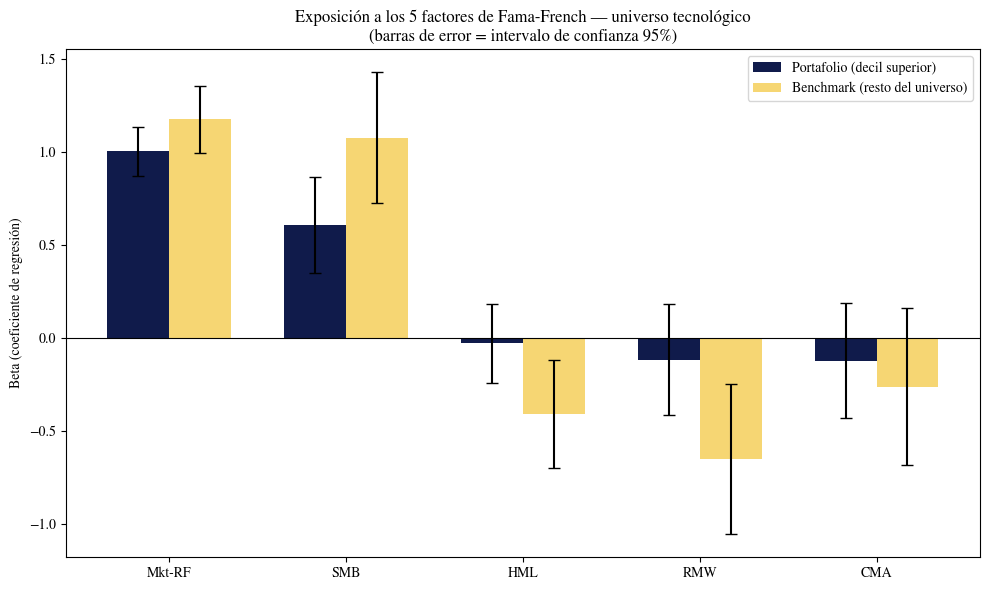

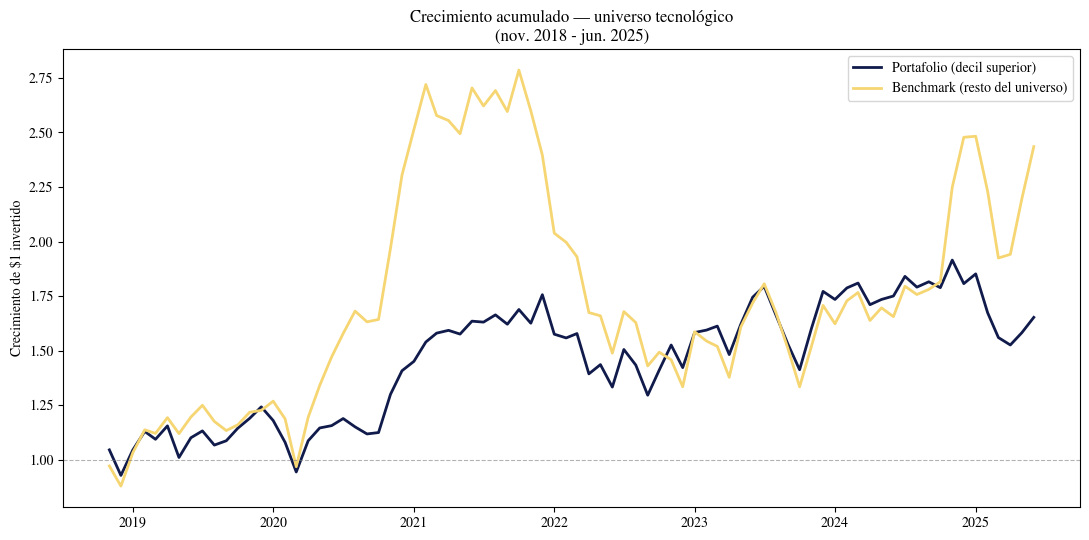

In [10]:
factores_nombres = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

betas_portafolio = modelo_portafolio.params[factores_nombres].values
betas_benchmark  = modelo_benchmark.params[factores_nombres].values
errores_portafolio = modelo_portafolio.bse[factores_nombres].values * 1.96
errores_benchmark  = modelo_benchmark.bse[factores_nombres].values * 1.96

x = np.arange(len(factores_nombres))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - ancho/2, betas_portafolio, ancho, yerr=errores_portafolio,
       label="Portafolio (decil superior)", color=tech_colors[0], capsize=4)
ax.bar(x + ancho/2, betas_benchmark, ancho, yerr=errores_benchmark,
       label="Benchmark (resto del universo)", color=tech_colors[5], capsize=4)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(factores_nombres, fontfamily=FUENTE)
ax.set_ylabel("Beta (coeficiente de regresión)", fontfamily=FUENTE)
ax.set_title("Exposición a los 5 factores de Fama-French — universo tecnológico\n"
             "(barras de error = intervalo de confianza 95%)",
             fontfamily=FUENTE, fontsize=12)
ax.legend(prop={"family": FUENTE})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.savefig("../salidas/grafico_betas_fama_french_tech.png", dpi=150)
plt.show()

# --- Crecimiento acumulado ---
riqueza_portafolio = (1 + series_mensuales_filtrado["retorno_portafolio"]).cumprod()
riqueza_benchmark  = (1 + series_mensuales_filtrado["retorno_benchmark"]).cumprod()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(riqueza_portafolio.index, riqueza_portafolio.values,
        label="Portafolio (decil superior)", color=tech_colors[0], linewidth=2)
ax.plot(riqueza_benchmark.index, riqueza_benchmark.values,
        label="Benchmark (resto del universo)", color=tech_colors[5], linewidth=2)
ax.axhline(1, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_ylabel("Crecimiento de $1 invertido", fontfamily=FUENTE)
ax.set_title("Crecimiento acumulado — universo tecnológico\n(nov. 2018 - jun. 2025)",
             fontfamily=FUENTE, fontsize=12)
ax.legend(prop={"family": FUENTE})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.savefig("../salidas/grafico_crecimiento_acumulado_tech.png", dpi=150)
plt.show()

HITO 7 — Parte 7: Visualizaciones finales
==================================================================
Fecha: 25/08/2026

Notebook: 07_backtesting_fama_french_tech.ipynb

Qué se hizo:
Se generaron dos gráficos: comparación de betas de los 5 factores con
intervalos de confianza, y crecimiento acumulado de $1 invertido en
cada estrategia a lo largo de 80 meses.

Resultado:
El gráfico de crecimiento acumulado revela que la ventaja de retorno
del benchmark se concentra en el rally especulativo de 2020-2022; en el
periodo posterior (2023-2024), el portafolio iguala o supera al
benchmark en varios tramos, mostrando un camino más estable. El
gráfico de betas confirma visualmente la mayor exposición negativa a
RMW del benchmark. Esto enriquece la interpretación del backtest: el
desempeño del portafolio no es uniformemente inferior en el tiempo,
sino que refleja un perfil de crecimiento más estable, con menor
participación en episodios especulativos y mayor resiliencia en
periodos de corrección de mercado -- un matiz relevante que la
comparación de métricas agregadas por sí sola no revela.